In [3]:
import pandas as pd

from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

# models = list_models('vllm') + ['siglip2_so400_16_512']
models = ['siglip_so400_14', 'siglip_so400_14_384', 'siglip_so400_14_378', 'gemma3_27b','gemma3_4b','chameleon_7b','chameleon_30b', 'paligemma2_10b_mix_224', 'paligemma2_10b_mix_448', 'paligemma2_28b_mix_224', 'paligemma2_28b_mix_448', 'paligemma2_3b_mix_224', 'paligemma2_3b_mix_448', 'paligemma_3b_224', 'paligemma_3b_448', 'paligemma_3b_mix_224', 'paligemma_3b_mix_448']

benchmarks = list_benchmarks()

outputhandler = OutputHandler(output_dir='/home/haltahan6/unibench/outputs', download_all_precomputed=False)

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
results = results[(results['task_name'] == 'multi_choice_classification') | (results['task_name'].isna())]
from unibench.common_utils.utils import get_model_mappings
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)

from unibench.common_utils.utils import get_benchmark_mappings
benchmark_mappings = get_benchmark_mappings("benchmark_type")
results["benchmark_type"] = results["benchmark_name"].map(benchmark_mappings)

/home/haltahan6/anaconda3/envs/vllm/lib/python3.10/site-packages/huggingface_hub/file_download.py:980: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(
Fetching 8641 files:   8%|▊         | 659/8641 [00:00<00:06, 1171.12it/s]

Fetching 8641 files: 100%|██████████| 8641/8641 [00:08<00:00, 1074.48it/s]


File not found:  /home/haltahan6/unibench/outputs/gemma3_27b/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_27b/coco_order.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_27b/countbench.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_27b/flickr30k_order.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_27b/sugarcrepe.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_27b/vg_attribution.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_27b/vg_relation.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_27b/winoground.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_4b/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_4b/coco_order.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_4b/countbench.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_4b/flickr30k_order.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_4b/sugarcrepe.f
File not found:  /home/haltahan6/unibe

/tmp/ipykernel_1624657/364720886.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1624657/364720886.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1624657/364720886.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1624657/364720886.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1624657/364720886.py:39: FutureWa

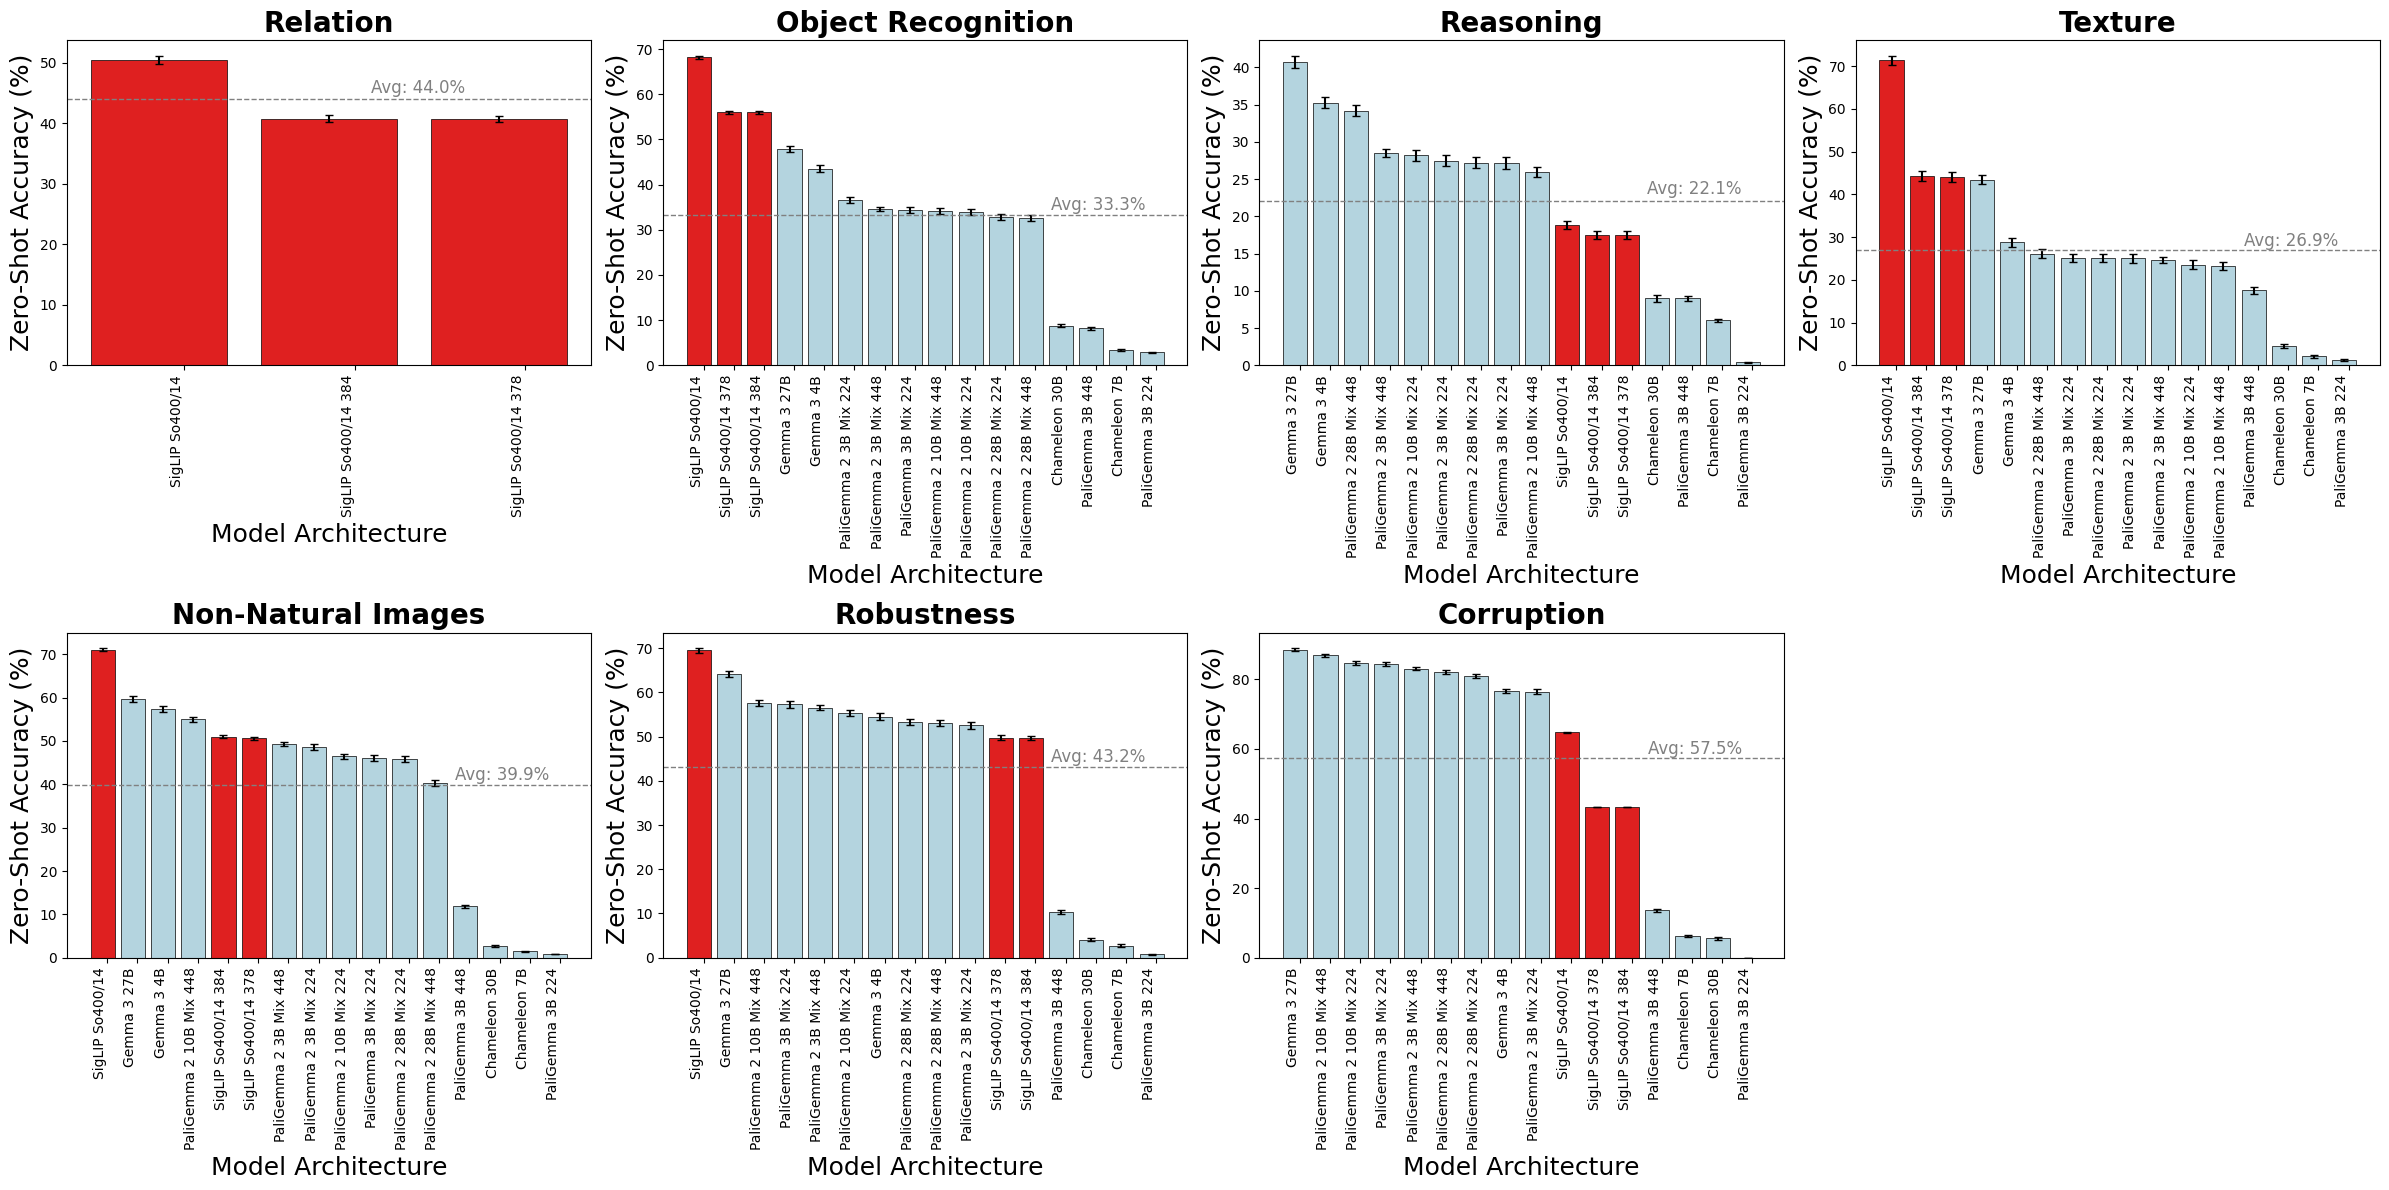

In [4]:
# --- Styling ---
LABEL_FONT_SIZE = 18
TICK_FONT_SIZE = 16
TITLE_FONT_SIZE = 20
ANNOTATION_FONT_SIZE = 12

# Get unique benchmark types
benchmark_types = results['benchmark_type'].unique()

# Create subplots
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for i, bench_type in enumerate(benchmark_types):
    # Filter data for this benchmark type
    type_results = results[results['benchmark_type'] == bench_type]
    
    # Compute average and SEM for this benchmark type
    df_mean_type = type_results.groupby(["model_name", "benchmark_name"]).correctness.mean()
    df_sem_type = type_results.groupby(["model_name", "benchmark_name"]).correctness.sem()
    
    type_performance = df_mean_type.reset_index().groupby("model_name").correctness.mean() * 100
    type_sem = df_sem_type.reset_index().groupby("model_name").correctness.mean() * 100
    
    type_model_data = pd.DataFrame({
        'model_name': type_performance.index,
        'performance': type_performance.values,
        'sem': type_sem.values
    })
    
    # Sort by performance
    sorted_type_models = type_model_data.sort_values('performance', ascending=False)
    
    # Create colors: red for SigLIP, light blue for others
    colors = ['red' if 'SigLIP' in name else 'lightblue' for name in sorted_type_models['model_name']]
    
    # Create barplot for this subplot
    ax = axes[i]
    sns.barplot(
        data=sorted_type_models,
        x='model_name',
        y='performance',
        palette=colors,
        edgecolor='black',
        linewidth=0.5,
        ax=ax
    )
    
    # Add error bars
    for j, row in enumerate(sorted_type_models.itertuples()):
        ax.errorbar(j, row.performance, yerr=row.sem, fmt='none', color='black',
                   capsize=3, elinewidth=1.5)
    
    # Customize this subplot
    ax.set_xlabel('Model Architecture', fontsize=LABEL_FONT_SIZE)
    ax.set_ylabel('Zero-Shot Accuracy (%)', fontsize=LABEL_FONT_SIZE)
    ax.set_title(f'{bench_type.title()}', fontsize=TITLE_FONT_SIZE, weight='bold')
    
    # Format x-axis labels
    tick_positions = [i + 0.15 for i in range(len(sorted_type_models))]
    ax.set_xticks(tick_positions)
    tick_labels = [name.split('_')[-1] if '_' in name else name for name in sorted_type_models['model_name']]
    ax.set_xticklabels(tick_labels, rotation=90, ha='right')
    
    # Add average line
    avg_performance = sorted_type_models['performance'].mean()
    ax.axhline(avg_performance, linestyle='--', color='gray', linewidth=1)
    ax.text(len(sorted_type_models) - 1.2, avg_performance + 1,
            f'Avg: {avg_performance:.1f}%', fontsize=ANNOTATION_FONT_SIZE,
            color='gray', ha='right')

# Hide any unused subplots
for i in range(len(benchmark_types), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()
